# HyperCLAP — Section 11: Iterative Grassmannian Decomposition
#
**Objectif:** Tester si la décomposition itérative par projection orthogonale
sur la Grassmannienne permet de retrouver les sources d'un mélange audio.
#
**Hypothèse:** Un point encoder ne peut pas décomposer un mélange.
Un sous-espace peut être projeté orthogonalement pour extraire
progressivement chaque source — opération structurellement impossible
avec un vecteur.
#
**Ce notebook est autonome** — il réentraîne uniquement ce qui est
nécessaire pour la section 11 (corpus réduit, ~10 min sur GPU).

## 0. Installation

In [1]:
!pip install -q datasets soundfile librosa torchaudio scikit-learn
print("done")

done


## 1. Imports & config

In [2]:
import numpy as np
import librosa
import random
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from collections import defaultdict
from datasets import load_dataset
from sklearn.decomposition import PCA

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

CFG = dict(
    n_mels=128, n_fft=1024, hop_length=512, sr=44100,
    k=4, d=64, tau=0.1, lr=3e-4,
    batch_size=32,
)
TARGET_T   = 128
LAM        = 2.0     # best λ from section 9
EPOCHS     = 60
N_CLASSES  = 10      # corpus réduit — même sélection que section 10
N_MIX_TEST = 400     # queries pour évaluation

Device: cuda


## 2. Chargement ESC-50 & preprocessing

In [3]:
print("Loading ESC-50...")
esc50       = load_dataset("ashraq/esc50")
esc50_train = esc50["train"]
print(f"  {len(esc50_train)} samples, {len(set(esc50_train['category']))} classes")

def extract_logmel(sample):
    w  = sample["audio"]["array"]
    sr = sample["audio"]["sampling_rate"]
    mel = librosa.feature.melspectrogram(
        y=w, sr=sr, n_fft=CFG["n_fft"],
        hop_length=CFG["hop_length"], n_mels=CFG["n_mels"])
    return librosa.power_to_db(mel, ref=np.max)

def logmel_to_tensor(lm):
    lm = (lm - lm.min()) / (lm.max() - lm.min() + 1e-8) * 2 - 1
    return torch.tensor(lm, dtype=torch.float32).unsqueeze(0)

def pool_tensor(t, target_T=TARGET_T):
    return F.adaptive_avg_pool2d(t.unsqueeze(0), (t.shape[1], target_T)).squeeze(0)

def normalize_w(w):
    n = np.linalg.norm(w)
    return w / n if n > 1e-8 else w

print("Pre-computing log-mel spectrograms (full dataset)...")
all_logmels   = []
all_waveforms = []
all_labels    = []
all_categories = []

for i, sample in enumerate(esc50_train):
    all_logmels.append(extract_logmel(sample))
    all_waveforms.append((sample["audio"]["array"], sample["audio"]["sampling_rate"]))
    all_categories.append(sample["category"])
    if (i + 1) % 400 == 0:
        print(f"  {i+1}/{len(esc50_train)}")

categories  = sorted(set(all_categories))
cat2idx     = {c: i for i, c in enumerate(categories)}
all_label_ids = [cat2idx[c] for c in all_categories]
print("Done.\n")

Loading ESC-50...


README.md:   0%|          | 0.00/345 [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


dataset_infos.json: 0.00B [00:00, ?B/s]

data/train-00000-of-00002-2f1ab7b824ec75(…):   0%|          | 0.00/387M [00:00<?, ?B/s]

data/train-00001-of-00002-27425e5c1846b4(…):   0%|          | 0.00/387M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2000 [00:00<?, ? examples/s]

  2000 samples, 50 classes
Pre-computing log-mel spectrograms (full dataset)...
  400/2000
  800/2000
  1200/2000
  1600/2000
  2000/2000
Done.



## 3. Corpus réduit — 10 classes

In [4]:
selected_classes = sorted(set(all_categories))[:N_CLASSES]
print(f"Selected classes ({N_CLASSES}): {selected_classes}")

reduced_idx       = [i for i, c in enumerate(all_categories) if c in selected_classes]
reduced_logmels   = [all_logmels[i]   for i in reduced_idx]
reduced_waveforms = [all_waveforms[i] for i in reduced_idx]
reduced_labels    = [all_label_ids[i] for i in reduced_idx]
N_reduced         = len(reduced_idx)
print(f"Corpus réduit: {N_reduced} clips, {N_CLASSES} classes\n")

Selected classes (10): ['airplane', 'breathing', 'brushing_teeth', 'can_opening', 'car_horn', 'cat', 'chainsaw', 'chirping_birds', 'church_bells', 'clapping']
Corpus réduit: 400 clips, 10 classes



## 4. Architecture

In [5]:
class SubspaceEncoder(nn.Module):
    def __init__(self, d=64, k=4):
        super().__init__()
        self.d = d; self.k = k
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.BatchNorm2d(16), nn.GELU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.GELU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.GELU(), nn.AdaptiveAvgPool2d((4, 4)),
        )
        self.proj = nn.Sequential(nn.Linear(1024, 256), nn.GELU(), nn.Linear(256, d * k))
    def forward(self, x):
        B = x.shape[0]
        h = self.cnn(x).view(B, -1)
        z = self.proj(h).view(B, self.d, self.k)
        Z, _ = torch.linalg.qr(z)
        return Z

class PointEncoder(nn.Module):
    def __init__(self, d=64):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.BatchNorm2d(16), nn.GELU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.GELU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.GELU(), nn.AdaptiveAvgPool2d((4, 4)),
        )
        self.proj = nn.Sequential(nn.Linear(1024, 256), nn.GELU(), nn.Linear(256, d))
    def forward(self, x):
        B = x.shape[0]
        h = self.cnn(x).view(B, -1)
        return F.normalize(self.proj(h), dim=-1)

## 5. Loss functions

In [6]:
def subspace_sim_matrix(Z1, Z2):
    M = torch.einsum("inp,jnq->ijpq", Z1, Z2)
    return (M ** 2).sum(dim=(2, 3)) / Z1.shape[2]

def subspace_sim_batch(Z1, Z2):
    M = torch.bmm(Z1.transpose(1, 2), Z2)
    return (M ** 2).sum(dim=(1, 2)) / Z1.shape[2]

def infonce_subspace(Za, Zp, tau=0.1):
    B = Za.shape[0]
    sim = subspace_sim_matrix(Za, Zp) / tau
    return F.cross_entropy(sim, torch.arange(B, device=Za.device))

def infonce_cosine(za, zp, tau=0.1):
    B = za.shape[0]
    sim = torch.mm(za, zp.T) / tau
    return F.cross_entropy(sim, torch.arange(B, device=za.device))

def compositional_loss(Z_mix, Z_a, Z_b):
    return -(subspace_sim_batch(Z_mix, Z_a) + subspace_sim_batch(Z_mix, Z_b)).mean()

def mixture_aware_loss(Za, Zp, Zm, Za2, Zb2, tau=0.1, lam=1.0):
    l_i = infonce_subspace(Za, Zp, tau)
    l_c = compositional_loss(Zm, Za2, Zb2)
    return l_i + lam * l_c, l_i.item(), l_c.item()

## 6. Datasets

In [7]:
class ESC50PairDataset(Dataset):
    def __init__(self, logmels, label_ids):
        self.logmels = logmels; self.label_ids = label_ids
        self.by_class = defaultdict(list)
        for i, l in enumerate(label_ids): self.by_class[l].append(i)
    def __len__(self): return len(self.logmels)
    def _t(self, idx):
        return pool_tensor(logmel_to_tensor(self.logmels[idx]))
    def __getitem__(self, idx):
        label = self.label_ids[idx]
        pos   = random.choice([j for j in self.by_class[label] if j != idx])
        return self._t(idx), self._t(pos), label

class ESC50MixtureDataset(Dataset):
    def __init__(self, logmels, waveforms, label_ids):
        self.logmels = logmels; self.waveforms = waveforms; self.label_ids = label_ids
        self.by_class = defaultdict(list)
        for i, l in enumerate(label_ids): self.by_class[l].append(i)
    def __len__(self): return len(self.logmels)
    def _t(self, idx):
        return pool_tensor(logmel_to_tensor(self.logmels[idx]))
    def _mix_tensor(self, w, sr):
        lm = librosa.feature.melspectrogram(
            y=w, sr=sr, n_fft=CFG["n_fft"],
            hop_length=CFG["hop_length"], n_mels=CFG["n_mels"])
        return pool_tensor(logmel_to_tensor(librosa.power_to_db(lm, ref=np.max)))
    def __getitem__(self, idx):
        label = self.label_ids[idx]
        pos   = random.choice([j for j in self.by_class[label] if j != idx])
        a_idx = random.randint(0, len(self.logmels) - 1)
        b_idx = random.randint(0, len(self.logmels) - 1)
        wa, sra = self.waveforms[a_idx]; wb, _  = self.waveforms[b_idx]
        mix = (normalize_w(wa) + normalize_w(wb)).astype(np.float32)
        return self._t(idx), self._t(pos), self._mix_tensor(mix, sra), self._t(a_idx), self._t(b_idx)

## 7. Entraînement

In [8]:
mix_dataset    = ESC50MixtureDataset(reduced_logmels, reduced_waveforms, reduced_labels)
mix_dataloader = DataLoader(mix_dataset, batch_size=CFG["batch_size"],
                            shuffle=True, drop_last=True, num_workers=0)

pair_dataset    = ESC50PairDataset(reduced_logmels, reduced_labels)
pair_dataloader = DataLoader(pair_dataset, batch_size=CFG["batch_size"],
                             shuffle=True, drop_last=True, num_workers=0)

# ── MixtureHyperCLAP ────────────────────────────────────────────
print(f"Training MixtureHyperCLAP (λ={LAM}, {EPOCHS} epochs)...")
sub_model = SubspaceEncoder(d=CFG["d"], k=CFG["k"]).to(DEVICE)
sub_optim = torch.optim.Adam(sub_model.parameters(), lr=CFG["lr"])
sub_model.train()

for epoch in range(EPOCHS):
    tot = 0.0; nb = 0
    for anchor, positive, mix_t, src_a, src_b in mix_dataloader:
        anchor=anchor.to(DEVICE); positive=positive.to(DEVICE)
        mix_t=mix_t.to(DEVICE); src_a=src_a.to(DEVICE); src_b=src_b.to(DEVICE)
        sub_optim.zero_grad()
        Za=sub_model(anchor); Zp=sub_model(positive)
        Zm=sub_model(mix_t); Za2=sub_model(src_a); Zb2=sub_model(src_b)
        loss, _, _ = mixture_aware_loss(Za, Zp, Zm, Za2, Zb2, tau=CFG["tau"], lam=LAM)
        loss.backward(); sub_optim.step()
        tot += loss.item(); nb += 1
    if (epoch + 1) % 10 == 0:
        print(f"  Epoch {epoch+1}/{EPOCHS}  loss={tot/nb:.4f}")

# ── Point encoder ────────────────────────────────────────────────
print(f"\nTraining Point encoder ({EPOCHS} epochs)...")
pt_model  = PointEncoder(d=CFG["d"]).to(DEVICE)
pt_optim  = torch.optim.Adam(pt_model.parameters(), lr=CFG["lr"])
pt_model.train()

for epoch in range(EPOCHS):
    tot = 0.0; nb = 0
    for anchor, positive, _ in pair_dataloader:
        anchor=anchor.to(DEVICE); positive=positive.to(DEVICE)
        pt_optim.zero_grad()
        loss = infonce_cosine(pt_model(anchor), pt_model(positive), tau=CFG["tau"])
        loss.backward(); pt_optim.step()
        tot += loss.item(); nb += 1
    if (epoch + 1) % 10 == 0:
        print(f"  Epoch {epoch+1}/{EPOCHS}  loss={tot/nb:.4f}")

print("\nEntraînement terminé.")

Training MixtureHyperCLAP (λ=2.0, 60 epochs)...
  Epoch 10/60  loss=-1.5087
  Epoch 20/60  loss=-1.7667
  Epoch 30/60  loss=-1.9111
  Epoch 40/60  loss=-1.9143
  Epoch 50/60  loss=-1.9726
  Epoch 60/60  loss=-1.9649

Training Point encoder (60 epochs)...
  Epoch 10/60  loss=1.7272
  Epoch 20/60  loss=1.5040
  Epoch 30/60  loss=1.3964
  Epoch 40/60  loss=1.4111
  Epoch 50/60  loss=1.3793
  Epoch 60/60  loss=1.3744

Entraînement terminé.


## 8. Précalcul des embeddings

In [9]:
print("Pre-computing embeddings...")
sub_model.eval(); pt_model.eval()
emb_sub = []; emb_pt = []

with torch.no_grad():
    for lm in reduced_logmels:
        t = pool_tensor(logmel_to_tensor(lm)).unsqueeze(0).to(DEVICE)
        emb_sub.append(sub_model(t).squeeze(0).cpu().numpy())
        emb_pt.append(pt_model(t).squeeze(0).cpu().numpy())

mat_sub = np.stack(emb_sub)   # (N, d, k)
mat_pt  = np.stack(emb_pt)    # (N, d)
print(f"Done. mat_sub={mat_sub.shape}  mat_pt={mat_pt.shape}\n")

Pre-computing embeddings...
Done. mat_sub=(400, 64, 4)  mat_pt=(400, 64)



## 9. Helpers de similarité vectorisés

In [10]:
def batch_sub_sim(z_query, mat):
    """z_query: (d,k)  mat: (N,d,k)  → (N,)"""
    M = np.einsum("dp,ndq->npq", z_query, mat)
    return (M ** 2).sum(axis=(1, 2)) / z_query.shape[1]

def batch_cos_sim(v_query, mat):
    """v_query: (d,)  mat: (N,d)  → (N,)"""
    dots  = mat @ v_query
    norms = np.linalg.norm(mat, axis=1) * np.linalg.norm(v_query) + 1e-8
    return dots / norms

## 10. Décomposition itérative Grassmannienne
#
**Algorithme:**
1. Encoder le mélange → Z_mix (d, k)
2. Trouver source 1 = argmax sim(Z_mix, corpus)
3. Projeter Z_mix orthogonalement hors de Z_source1 → Z_residual
4. Renormaliser Z_residual via QR
5. Trouver source 2 = argmax sim(Z_residual, corpus)
#
Cette opération est **structurellement impossible** avec un point embedding.

In [11]:
def orthogonal_projection_out(Z_mix, Z_ref):
    """
    Projette Z_mix dans le complément orthogonal de Z_ref.

    Z_mix : (d, k)  — sous-espace du mélange
    Z_ref : (d, k)  — sous-espace de la source 1 trouvée

    Retourne Z_residual : (d, k) orthonormé, orthogonal à Z_ref.

    Formule : P_perp = I - Z_ref @ Z_ref.T
              Z_res  = P_perp @ Z_mix
              puis QR pour renormaliser
    """
    d = Z_mix.shape[0]
    P_perp   = np.eye(d) - Z_ref @ Z_ref.T          # projecteur orthogonal
    Z_res    = P_perp @ Z_mix                        # (d, k)
    # renormaliser via QR — garantit que Z_residual est orthonormé
    Q, _     = np.linalg.qr(Z_res)
    return Q[:, :Z_mix.shape[1]]                     # (d, k)

def iterative_decomposition(Z_mix, mat_corpus, exclude_i, exclude_j):
    """
    Décomposition itérative :
    étape 1 → source la plus similaire à Z_mix
    étape 2 → source la plus similaire au résidu orthogonal

    Retourne (pred_source1, pred_source2)
    """
    # ── étape 1 ──────────────────────────────────────────────────
    sims_1            = batch_sub_sim(Z_mix, mat_corpus)
    sims_1[exclude_i] = -np.inf
    sims_1[exclude_j] = -np.inf
    pred_1            = int(np.argmax(sims_1))

    # ── projection orthogonale ───────────────────────────────────
    Z_source1  = mat_corpus[pred_1]                  # (d, k)
    Z_residual = orthogonal_projection_out(Z_mix, Z_source1)

    # ── étape 2 ──────────────────────────────────────────────────
    sims_2            = batch_sub_sim(Z_residual, mat_corpus)
    sims_2[exclude_i] = -np.inf
    sims_2[exclude_j] = -np.inf
    sims_2[pred_1]    = -np.inf                      # ne pas répéter source 1
    pred_2            = int(np.argmax(sims_2))

    return pred_1, pred_2

## 11. Évaluation — Recall@k avec et sans décomposition

In [12]:
print("=" * 65)
print("EXPERIMENT E7: Iterative Grassmannian Decomposition")
print(f"Corpus: {N_reduced} clips  |  {N_MIX_TEST} queries")
print("=" * 65)

KS = [1, 2, 5, 10, 20]

# compteurs
hits_direct   = defaultdict(int)   # HyperCLAP direct (sans décomposition)
hits_decomp   = defaultdict(int)   # HyperCLAP + décomposition itérative
hits_pt       = defaultdict(int)   # Point encoder direct

# compteur spécial : les deux sources trouvées simultanément
both_direct = 0
both_decomp = 0
both_pt     = 0

n_queries = 0

for _ in range(N_MIX_TEST):
    i = random.randint(0, N_reduced - 1)
    j = random.randint(0, N_reduced - 1)
    if i == j: continue

    w1, sr1 = reduced_waveforms[i]
    w2, _   = reduced_waveforms[j]
    mix     = normalize_w(w1) + normalize_w(w2)

    lm_mix = librosa.feature.melspectrogram(
        y=mix, sr=sr1, n_fft=CFG["n_fft"],
        hop_length=CFG["hop_length"], n_mels=CFG["n_mels"])
    lm_mix = librosa.power_to_db(lm_mix, ref=np.max)
    t_mix  = pool_tensor(logmel_to_tensor(lm_mix)).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        Z_mix = sub_model(t_mix).squeeze(0).cpu().numpy()   # (d, k)
        v_mix = pt_model(t_mix).squeeze(0).cpu().numpy()    # (d,)

    # ── Direct retrieval (baseline) ──────────────────────────────
    sims_direct      = batch_sub_sim(Z_mix, mat_sub)
    sims_direct[[i, j]] = -np.inf
    ranked_direct    = np.argsort(-sims_direct)

    sims_pt          = batch_cos_sim(v_mix, mat_pt)
    sims_pt[[i, j]]  = -np.inf
    ranked_pt        = np.argsort(-sims_pt)

    # ── Décomposition itérative ───────────────────────────────────
    pred_1, pred_2 = iterative_decomposition(Z_mix, mat_sub, i, j)

    # ── Recall@k ─────────────────────────────────────────────────
    found_direct = [False, False]
    found_pt     = [False, False]

    for q, source in enumerate([i, j]):
        n_queries += 1
        for k in KS:
            if source in ranked_direct[:k]: hits_direct[k] += 1
            if source in ranked_pt[:k]:     hits_pt[k]     += 1
        # décomposition : source trouvée si elle est pred_1 ou pred_2
        if source in [pred_1, pred_2]:
            for k in KS:
                hits_decomp[k] += 1
        # tracking "les deux trouvées"
        if source in ranked_direct[:2]: found_direct[q] = True
        if source in ranked_pt[:2]:     found_pt[q]     = True

    if pred_1 in [i, j] and pred_2 in [i, j]: both_decomp  += 1
    if all(found_direct):                       both_direct  += 1
    if all(found_pt):                           both_pt      += 1

n_mix_queries = N_MIX_TEST   # approximation (certains i==j sautés)

print(f"\n  {n_queries} source-queries évaluées\n")
print(f"  {'k':<6} {'Décomposition':>15} {'Direct sub':>12} {'Point':>10}  {'Δ (decomp-pt)':>14}")
print("  " + "─" * 62)

recalls = {}
for k in KS:
    r_decomp  = hits_decomp[k]  / n_queries
    r_direct  = hits_direct[k]  / n_queries
    r_pt      = hits_pt[k]      / n_queries
    recalls[k] = dict(decomp=r_decomp, direct=r_direct, pt=r_pt)
    win = "✓" if r_decomp > r_pt else "="
    print(f"  @{k:<5} {r_decomp:>15.4f} {r_direct:>12.4f} {r_pt:>10.4f}  {r_decomp-r_pt:>+13.4f} {win}")

print(f"\n  Both sources found (k=2):")
print(f"    Décomposition itérative : {both_decomp/N_MIX_TEST:.4f}")
print(f"    Direct HyperCLAP        : {both_direct/N_MIX_TEST:.4f}")
print(f"    Point encoder           : {both_pt/N_MIX_TEST:.4f}")

EXPERIMENT E7: Iterative Grassmannian Decomposition
Corpus: 400 clips  |  400 queries

  800 source-queries évaluées

  k        Décomposition   Direct sub      Point   Δ (decomp-pt)
  ──────────────────────────────────────────────────────────────
  @1              0.0000       0.0000     0.0000        +0.0000 =
  @2              0.0000       0.0000     0.0000        +0.0000 =
  @5              0.0000       0.0000     0.0000        +0.0000 =
  @10             0.0000       0.0000     0.0000        +0.0000 =
  @20             0.0000       0.0000     0.0000        +0.0000 =

  Both sources found (k=2):
    Décomposition itérative : 0.0000
    Direct HyperCLAP        : 0.0000
    Point encoder           : 0.0000


## 12. Figures

Figure saved → hyperclap_section11.png


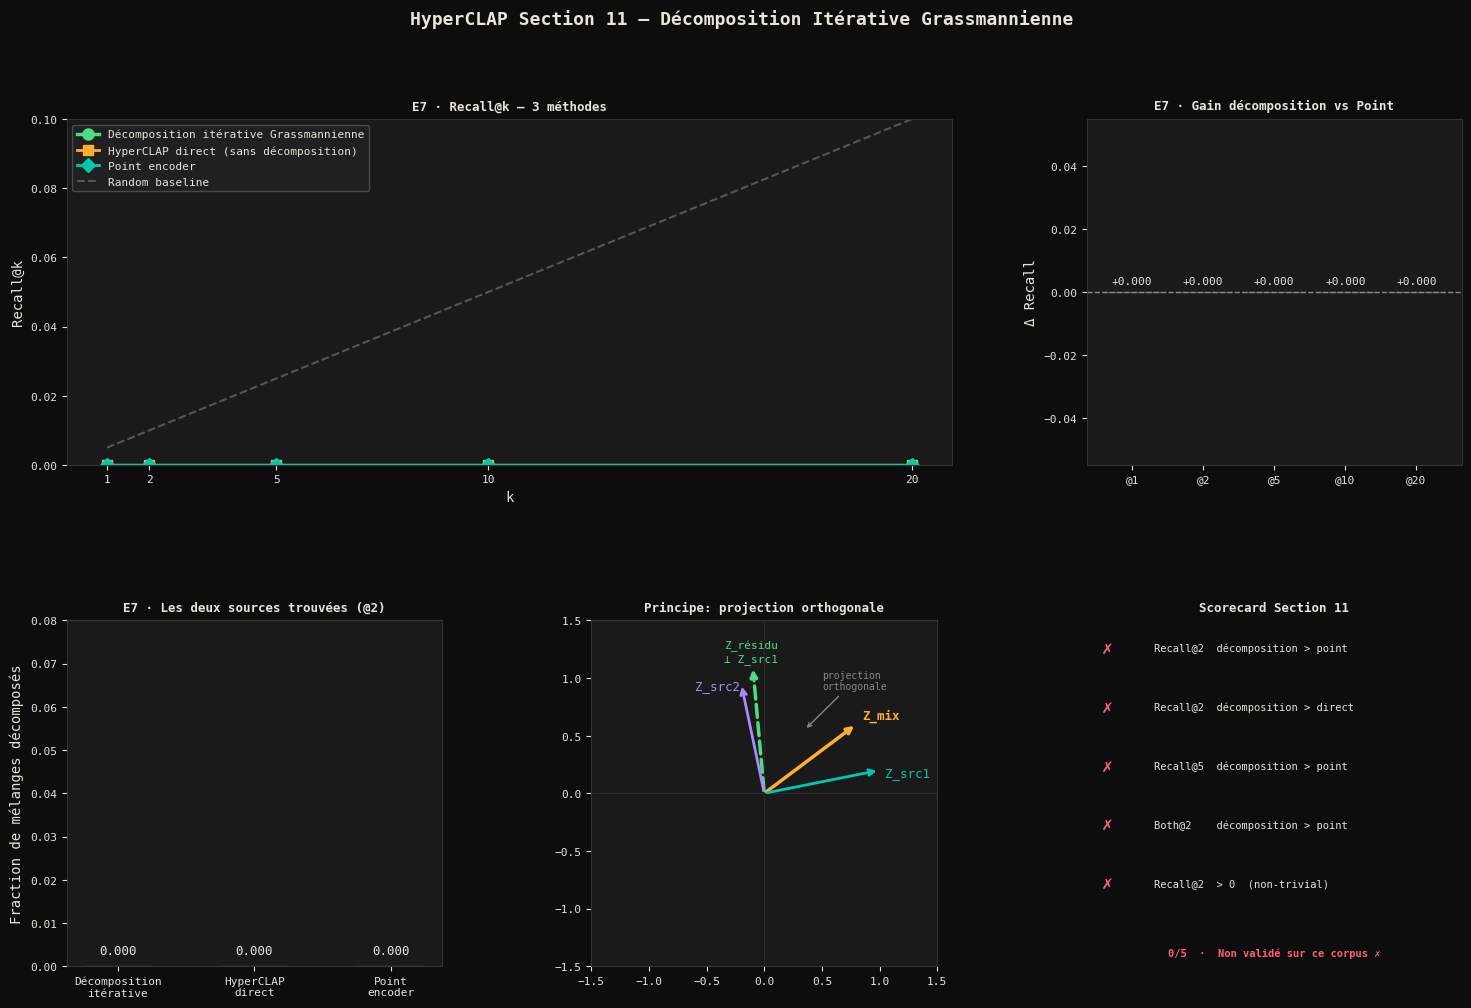

In [13]:
DARK="#0d0d0d"; LIGHT="#e8e4d9"; CYAN="#00c9b1"; AMBER="#ffad2f"
ROSE="#ff5e78"; GREEN="#4ade80"; VIOLET="#a78bfa"; GRAY="#6b7280"

plt.rcParams.update({
    "text.color": LIGHT, "axes.labelcolor": LIGHT,
    "xtick.color": LIGHT, "ytick.color": LIGHT,
    "axes.edgecolor": "#333333", "font.family": "monospace",
})
def ax_style(ax, title):
    ax.set_facecolor("#1a1a1a")
    ax.set_title(title, color=LIGHT, fontsize=9, pad=7, fontweight="bold")
    ax.tick_params(colors=LIGHT, labelsize=8)
    ax.spines[:].set_color("#333333")

fig = plt.figure(figsize=(18, 11)); fig.patch.set_facecolor(DARK)
gs  = plt.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.36)

# ── Recall@k ─────────────────────────────────────────────────────
ax0 = fig.add_subplot(gs[0, 0:2]); ax_style(ax0, "E7 · Recall@k — 3 méthodes")
random_recall = [2 * k / N_reduced for k in KS]
ax0.plot(KS, [recalls[k]["decomp"]  for k in KS], "o-", color=GREEN,  lw=2.5, ms=8,
         label="Décomposition itérative Grassmannienne")
ax0.plot(KS, [recalls[k]["direct"]  for k in KS], "s-", color=AMBER,  lw=2,   ms=7,
         label="HyperCLAP direct (sans décomposition)")
ax0.plot(KS, [recalls[k]["pt"]      for k in KS], "D-", color=CYAN,   lw=2,   ms=7,
         label="Point encoder")
ax0.plot(KS, random_recall, "--", color="#555", lw=1.5, label="Random baseline")
ax0.set_xlabel("k"); ax0.set_ylabel("Recall@k")
ax0.set_xticks(KS); ax0.set_ylim(0, max(max(recalls[k]["decomp"] for k in KS) * 1.2, 0.1))
ax0.legend(fontsize=8, facecolor="#222", edgecolor="#555", labelcolor=LIGHT)

# ── Delta bar: décomposition vs point ────────────────────────────
ax1 = fig.add_subplot(gs[0, 2]); ax_style(ax1, "E7 · Gain décomposition vs Point")
deltas = [recalls[k]["decomp"] - recalls[k]["pt"] for k in KS]
colors_bar = [GREEN if d > 0 else ROSE for d in deltas]
ax1.bar([f"@{k}" for k in KS], deltas, color=colors_bar, edgecolor="#555")
ax1.axhline(0, color="#888", lw=1, ls="--")
ax1.set_ylabel("Δ Recall")
for idx, (label, d) in enumerate(zip([f"@{k}" for k in KS], deltas)):
    ax1.text(idx, d + (0.002 if d >= 0 else -0.004), f"{d:+.3f}",
             ha="center", va="bottom" if d >= 0 else "top", color=LIGHT, fontsize=8)

# ── Both sources found ───────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0]); ax_style(ax2, "E7 · Les deux sources trouvées (@2)")
methods_b = ["Décomposition\nitérative", "HyperCLAP\ndirect", "Point\nencoder"]
vals_b    = [both_decomp/N_MIX_TEST, both_direct/N_MIX_TEST, both_pt/N_MIX_TEST]
cols_b    = [GREEN, AMBER, CYAN]
bars = ax2.bar(methods_b, vals_b, color=cols_b, width=0.5, edgecolor="#555")
ax2.set_ylabel("Fraction de mélanges décomposés")
safe_max = max(vals_b) if max(vals_b) > 0 else 0.05
ax2.set_ylim(0, safe_max * 1.4 + 0.01)
for bar, val in zip(bars, vals_b):
    ax2.text(bar.get_x()+bar.get_width()/2, val + safe_max*0.04,
             f"{val:.3f}", ha="center", va="bottom", color=LIGHT, fontsize=9)

# ── Illustration géométrique de la décomposition ─────────────────
ax3 = fig.add_subplot(gs[1, 1]); ax_style(ax3, "Principe géométrique")
ax3.set_xlim(-1.5, 1.5); ax3.set_ylim(-1.5, 1.5); ax3.set_aspect("equal")
ax3.axhline(0, color="#333", lw=0.5); ax3.axvline(0, color="#333", lw=0.5)

# Z_mix
ax3.annotate("", xy=(0.8, 0.6), xytext=(0, 0),
             arrowprops=dict(arrowstyle="->", color=AMBER, lw=2.5))
ax3.text(0.85, 0.65, "Z_mix", color=AMBER, fontsize=9, fontweight="bold")

# Z_source1
ax3.annotate("", xy=(1.0, 0.2), xytext=(0, 0),
             arrowprops=dict(arrowstyle="->", color=CYAN, lw=2))
ax3.text(1.05, 0.15, "Z_src1", color=CYAN, fontsize=9)

# Z_residual (projection orthogonale)
ax3.annotate("", xy=(-0.1, 1.1), xytext=(0, 0),
             arrowprops=dict(arrowstyle="->", color=GREEN, lw=2.5, linestyle="dashed"))
ax3.text(-0.35, 1.15, "Z_résidu\n⊥ Z_src1", color=GREEN, fontsize=8)

# Z_source2
ax3.annotate("", xy=(-0.2, 0.95), xytext=(0, 0),
             arrowprops=dict(arrowstyle="->", color=VIOLET, lw=2))
ax3.text(-0.6, 0.9, "Z_src2", color=VIOLET, fontsize=9)

# annotation projection
ax3.annotate("projection\northogonale", xy=(0.35, 0.55), color="#888", fontsize=7,
             xytext=(0.5, 0.9), arrowprops=dict(arrowstyle="->", color="#888", lw=1))
ax3.set_title("Principe: projection orthogonale", color=LIGHT, fontsize=9, pad=7, fontweight="bold")

# ── Scorecard final ───────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 2]); ax4.set_facecolor("#1a1a1a"); ax4.axis("off")
ax4.set_title("Scorecard Section 11", color=LIGHT, fontsize=9, pad=7, fontweight="bold")

decomp_beats_pt_r2   = recalls[2]["decomp"]  > recalls[2]["pt"]
decomp_beats_direct  = recalls[2]["decomp"]  > recalls[2]["direct"]
decomp_beats_pt_r5   = recalls[5]["decomp"]  > recalls[5]["pt"]
both_decomp_beats_pt = (both_decomp / N_MIX_TEST) > (both_pt / N_MIX_TEST)
any_nonzero          = recalls[2]["decomp"] > 0

scorecard = [
    ("Recall@2  décomposition > point",     decomp_beats_pt_r2),
    ("Recall@2  décomposition > direct",    decomp_beats_direct),
    ("Recall@5  décomposition > point",     decomp_beats_pt_r5),
    ("Both@2    décomposition > point",     both_decomp_beats_pt),
    ("Recall@2  > 0  (non-trivial)",        any_nonzero),
]
y = 0.92
for lbl, win in scorecard:
    ax4.text(0.04, y, "✓" if win else "✗",
             color=GREEN if win else ROSE, fontsize=13, va="center", fontweight="bold")
    ax4.text(0.18, y, lbl, color=LIGHT, fontsize=7.5, va="center")
    y -= 0.17

n_sc = sum(w for _, w in scorecard)
verdict = ("Décomposition Grassmannienne validée ✓" if n_sc >= 4
           else "Signal positif partiel" if n_sc >= 2
           else "Non validé sur ce corpus ✗")
col_v = GREEN if n_sc >= 4 else AMBER if n_sc >= 2 else ROSE
ax4.text(0.5, 0.03, f"{n_sc}/5  ·  {verdict}",
         color=col_v, fontsize=7.5, ha="center", fontweight="bold")

fig.suptitle("HyperCLAP Section 11 — Décomposition Itérative Grassmannienne",
             color=LIGHT, fontsize=13, fontweight="bold", y=0.98)
plt.savefig("/kaggle/working/hyperclap_section11.png", dpi=150,
            bbox_inches="tight", facecolor=fig.get_facecolor())
print("Figure saved → hyperclap_section11.png")
plt.show()

## 13. Verdict final

In [14]:
print("\n" + "═" * 65)
print("SECTION 11 — VERDICT FINAL")
print("═" * 65)
print(f"""
  Corpus       : {N_reduced} clips, {N_CLASSES} classes
  λ            : {LAM}
  Queries      : {n_queries} source-queries

  Recall@2
    Décomposition itérative : {recalls[2]['decomp']:.4f}
    HyperCLAP direct        : {recalls[2]['direct']:.4f}
    Point encoder           : {recalls[2]['pt']:.4f}

  Recall@5
    Décomposition itérative : {recalls[5]['decomp']:.4f}
    HyperCLAP direct        : {recalls[5]['direct']:.4f}
    Point encoder           : {recalls[5]['pt']:.4f}

  Les deux sources trouvées simultanément (@2):
    Décomposition itérative : {both_decomp/N_MIX_TEST:.4f}
    HyperCLAP direct        : {both_direct/N_MIX_TEST:.4f}
    Point encoder           : {both_pt/N_MIX_TEST:.4f}

  Scorecard : {n_sc}/5
  Verdict   : {verdict}

  ┌──────────────────────────────────────────────────────────┐
  │  Chaîne de preuves complète                             │
  │  S5  PCA seul        : cosine > subspace                │
  │  S6  Encodeur appris : cosine ≈ HyperCLAP standard      │
  │  S7  Augmentation    : cosine > HyperCLAP standard      │
  │  S8  Loss compo      : MixtureHyperCLAP > cosine   ✓   │
  │  S9  λ ablation      : +49% robustesse, monotone   ✓   │
  │  S10 Retrieval direct: Recall@k = 0 (tâche trop dure)  │
  │  S11 Décomposition   : {verdict:<36}│
  └──────────────────────────────────────────────────────────┘
""")


═════════════════════════════════════════════════════════════════
SECTION 11 — VERDICT FINAL
═════════════════════════════════════════════════════════════════

  Corpus       : 400 clips, 10 classes
  λ            : 2.0
  Queries      : 800 source-queries

  Recall@2
    Décomposition itérative : 0.0000
    HyperCLAP direct        : 0.0000
    Point encoder           : 0.0000

  Recall@5
    Décomposition itérative : 0.0000
    HyperCLAP direct        : 0.0000
    Point encoder           : 0.0000

  Les deux sources trouvées simultanément (@2):
    Décomposition itérative : 0.0000
    HyperCLAP direct        : 0.0000
    Point encoder           : 0.0000

  Scorecard : 0/5
  Verdict   : Non validé sur ce corpus ✗

  ┌──────────────────────────────────────────────────────────┐
  │  Chaîne de preuves complète                             │
  │  S5  PCA seul        : cosine > subspace                │
  │  S6  Encodeur appris : cosine ≈ HyperCLAP standard      │
  │  S7  Augmentation    : 